In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [2]:
time_series_data = pd.read_csv("C://Users//nmims.student//Downloads//AirPassengers.xls")
time_series_data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
time_series_data.shape

(144, 2)

In [4]:
time_series_data['Month'] = pd.to_datetime(time_series_data['Month'])
time_series_data = time_series_data.set_index('Month')

In [5]:
time_series_data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
time_series_data.shape

(144, 1)

Text(0, 0.5, '#Passengers')

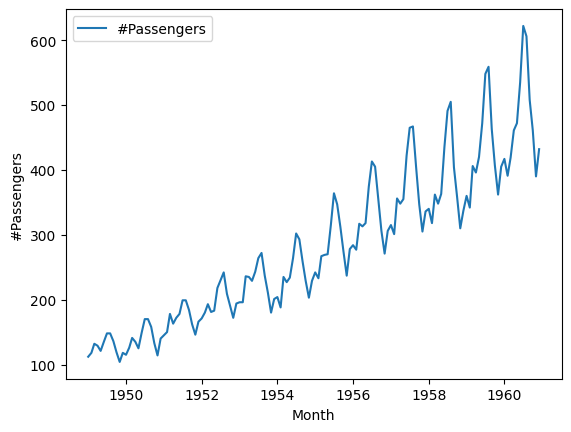

In [7]:
sns.lineplot(time_series_data)
plt.ylabel("#Passengers")

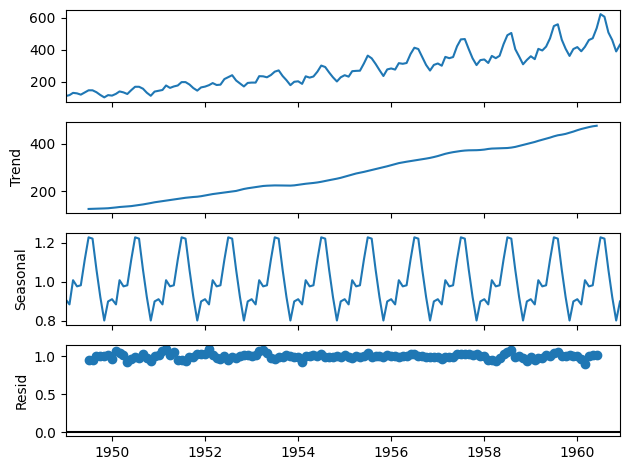

In [8]:
result=seasonal_decompose(time_series_data[['#Passengers']],model='multiplicative',period=12)
result.plot()
plt.show()

In [9]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [10]:
import pymannkendall as mk
#perform Mann-Kendall test
#h0: there is no monotonic trend in the series

In [11]:
mk.original_test(time_series_data['#Passengers'])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(14.381610025544802), Tau=np.float64(0.8087606837606838), s=np.float64(8327.0), var_s=np.float64(335164.3333333333), slope=np.float64(2.451216287678477), intercept=np.float64(90.23803543098887))

#pvalue<0.5 => rejecxt h0 there is trend presnt

In [12]:
train_df = time_series_data[:int( time_series_data.shape[0]*0.7)]
test_df =  time_series_data[int( time_series_data.shape[0]*0.7):]

In [13]:
train_df.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [14]:
from statsmodels.tsa.api import SimpleExpSmoothing

In [15]:
model = SimpleExpSmoothing(train_df)
model_single_fit= model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single)

1957-05-01    348.0
1957-06-01    348.0
1957-07-01    348.0
1957-08-01    348.0
1957-09-01    348.0
1957-10-01    348.0
1957-11-01    348.0
1957-12-01    348.0
1958-01-01    348.0
1958-02-01    348.0
1958-03-01    348.0
1958-04-01    348.0
1958-05-01    348.0
1958-06-01    348.0
1958-07-01    348.0
1958-08-01    348.0
1958-09-01    348.0
1958-10-01    348.0
1958-11-01    348.0
1958-12-01    348.0
1959-01-01    348.0
1959-02-01    348.0
1959-03-01    348.0
1959-04-01    348.0
1959-05-01    348.0
1959-06-01    348.0
1959-07-01    348.0
1959-08-01    348.0
1959-09-01    348.0
1959-10-01    348.0
1959-11-01    348.0
1959-12-01    348.0
1960-01-01    348.0
1960-02-01    348.0
1960-03-01    348.0
1960-04-01    348.0
1960-05-01    348.0
1960-06-01    348.0
1960-07-01    348.0
1960-08-01    348.0
1960-09-01    348.0
1960-10-01    348.0
1960-11-01    348.0
1960-12-01    348.0
Freq: MS, dtype: float64


In [17]:
model_single_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

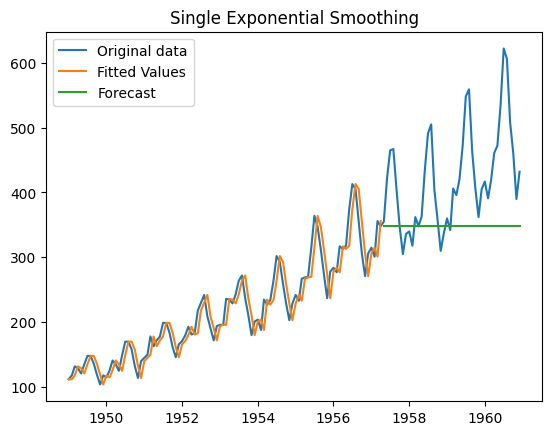

In [18]:
plt.plot(time_series_data , label = "Original data")
plt.plot(model_single_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_single , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Single Exponential Smoothing")
plt.legend()
plt.show()

In [19]:
from statsmodels.tsa.api import Holt

model_double = Holt(train_df)
model_double_fit = model_double.fit() 

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [20]:
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double)

1957-05-01    352.234328
1957-06-01    356.468656
1957-07-01    360.702983
1957-08-01    364.937311
1957-09-01    369.171639
1957-10-01    373.405966
1957-11-01    377.640294
1957-12-01    381.874622
1958-01-01    386.108949
1958-02-01    390.343277
1958-03-01    394.577605
1958-04-01    398.811932
1958-05-01    403.046260
1958-06-01    407.280588
1958-07-01    411.514915
1958-08-01    415.749243
1958-09-01    419.983571
1958-10-01    424.217898
1958-11-01    428.452226
1958-12-01    432.686554
1959-01-01    436.920881
1959-02-01    441.155209
1959-03-01    445.389537
1959-04-01    449.623865
1959-05-01    453.858192
1959-06-01    458.092520
1959-07-01    462.326848
1959-08-01    466.561175
1959-09-01    470.795503
1959-10-01    475.029831
1959-11-01    479.264158
1959-12-01    483.498486
1960-01-01    487.732814
1960-02-01    491.967141
1960-03-01    496.201469
1960-04-01    500.435797
1960-05-01    504.670124
1960-06-01    508.904452
1960-07-01    513.138780
1960-08-01    517.373107


In [21]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(0.006851687665374291),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

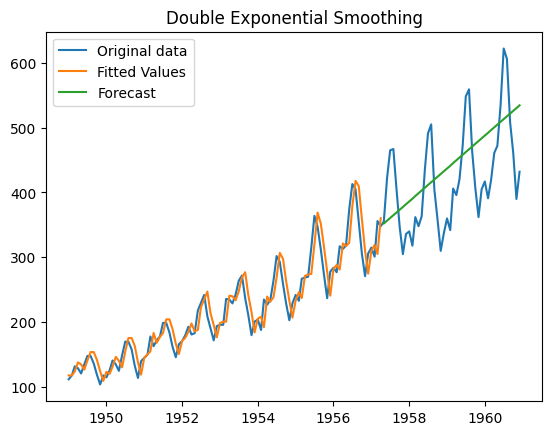

In [22]:
plt.plot(time_series_data , label = "Original data")
plt.plot(model_double_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_double , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Double Exponential Smoothing")
plt.legend()
plt.show()

In [23]:
from statsmodels.tsa.api import ExponentialSmoothing

In [24]:
model_triple = ExponentialSmoothing(train_df , seasonal_periods=12 , trend ="add" , seasonal = "add")
model_triple_fit = model_triple.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [25]:
model_triple_fit.params

{'smoothing_level': np.float64(0.2550388055224319),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.744961194477568),
 'damping_trend': nan,
 'initial_level': np.float64(118.79990413477267),
 'initial_trend': np.float64(2.325181116804309),
 'initial_seasons': array([ -9.11885194,  -3.51989856,   8.9612201 ,   3.68346559,
         -5.07532303,   9.02414948,  21.23695234,  18.80658927,
          4.67759866, -14.13310871, -28.56400717, -11.95740273]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [26]:
forecast_triple = model_triple_fit.forecast(len(test_df))

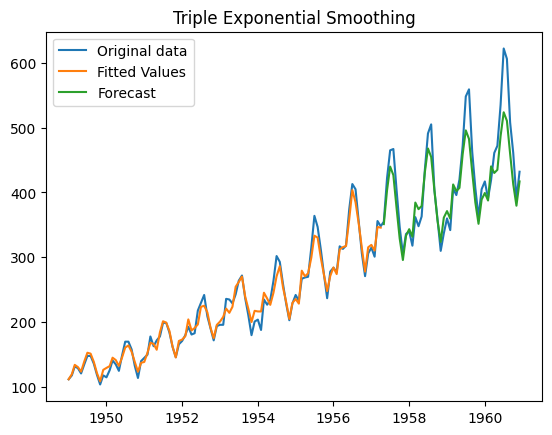

In [27]:
plt.plot(time_series_data , label = "Original data")
plt.plot(model_triple_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_triple , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Triple Exponential Smoothing")
plt.legend()
plt.show()

In [28]:
model_triplee = ExponentialSmoothing(train_df , seasonal_periods=12 , trend ="add" , seasonal = "mul")
model_triplee_fit = model_triplee.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1340: RuntimeWarning: divide by zero encountered in scalar divide
  lvls[i] = y_alpha[i - 1] / s[i - 1] + (
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1344: RuntimeWarning: invalid value encountered in scalar multiply
  b[i] = (beta * detrend(lvls[i], lvls[i - 1])) + (


In [29]:
model_triplee_fit.params

{'smoothing_level': np.float64(1.4901161193847656e-08),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': nan,
 'initial_level': np.float64(126.97141791449647),
 'initial_trend': np.float64(58.764030194523365),
 'initial_seasons': array([    0.        ,     0.        ,     0.        ,  5740.78358761,
         9504.12463536, 12109.68563937, 11075.62388667,     0.        ,
            0.        ,   547.40304488,  2248.49324605,     0.        ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [30]:
forecast_triplee = model_triplee_fit.forecast(len(test_df))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1340: RuntimeWarning: divide by zero encountered in scalar divide
  lvls[i] = y_alpha[i - 1] / s[i - 1] + (
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1344: RuntimeWarning: invalid value encountered in scalar multiply
  b[i] = (beta * detrend(lvls[i], lvls[i - 1])) + (


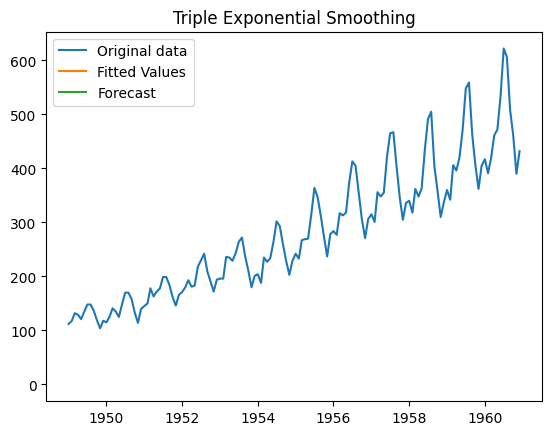

In [31]:
plt.plot(time_series_data , label = "Original data")
plt.plot(model_triplee_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_triplee , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Triple Exponential Smoothing")
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error ,mean_absolute_error, mean_absolute_percentage_error
mape_test_add = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triple)
print("MAPE for Test Data:" , mape_test_add)

MAPE for Test Data: 0.05397114402516979


In [33]:
# from sklearn.metrics import mean_squared_error ,mean_absolute_error, mean_absolute_percentage_error
# mape_test_mul = mean_absolute_percentage_error(test_df['#Passengers'], forecast_triplee)
# print("MAPE for Test Data:" , mape_test_mul)

ValueError: Input contains NaN.

# Stationary

In [62]:
#ADF Test
#Null Hypothesis (H0): Series is non Stationary, i.e, series has a unit root
#Alternate Hypoyhesis (H1) : Series is non-stationary, i.e, series has no unit root

In [34]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(time_series_data['#Passengers'])

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


In [45]:
#KPSS Test
#Null Hypothesis (H0): Series is trend stationary or series has no unit root.
#Alternate Hypoyhesis (H1) : Series is non-stationary, or series has a unit root.
#p-value < 0.05 - Reject Null Hypothesis (H0)

In [36]:
from statsmodels.tsa.stattools import kpss
kp = kpss(time_series_data['#Passengers'])
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.01


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_20652\4161866113.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(time_series_data['#Passengers'])


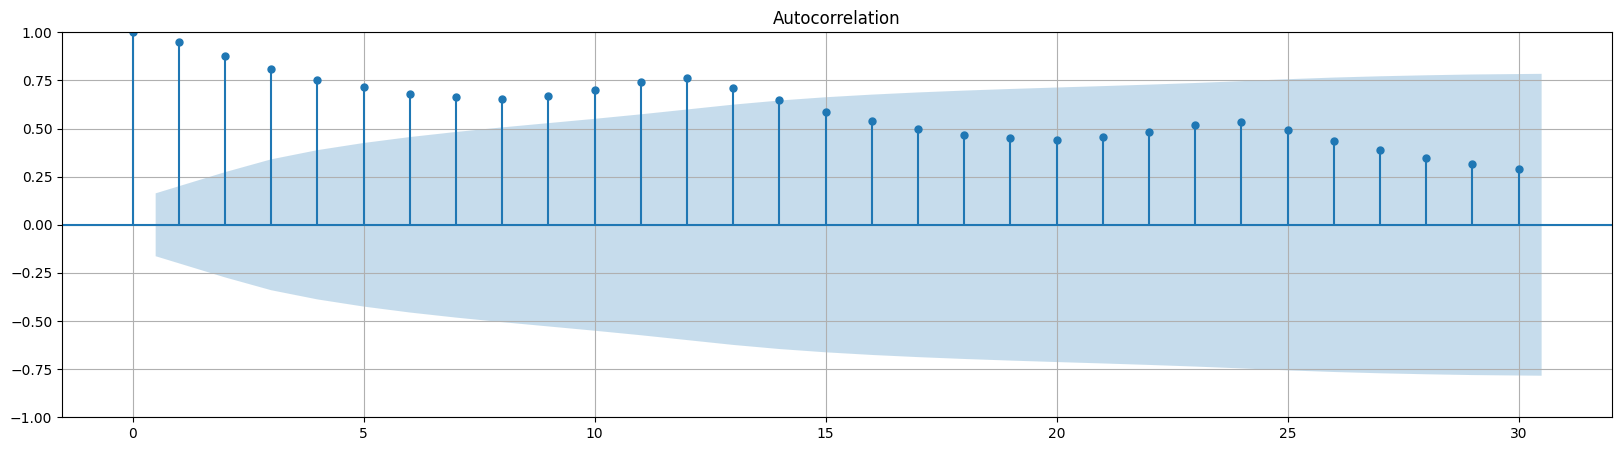

In [38]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(20,5))
plt.grid()
plot_acf(time_series_data['#Passengers'],ax=plt.gca(),lags=30)
plt.show()

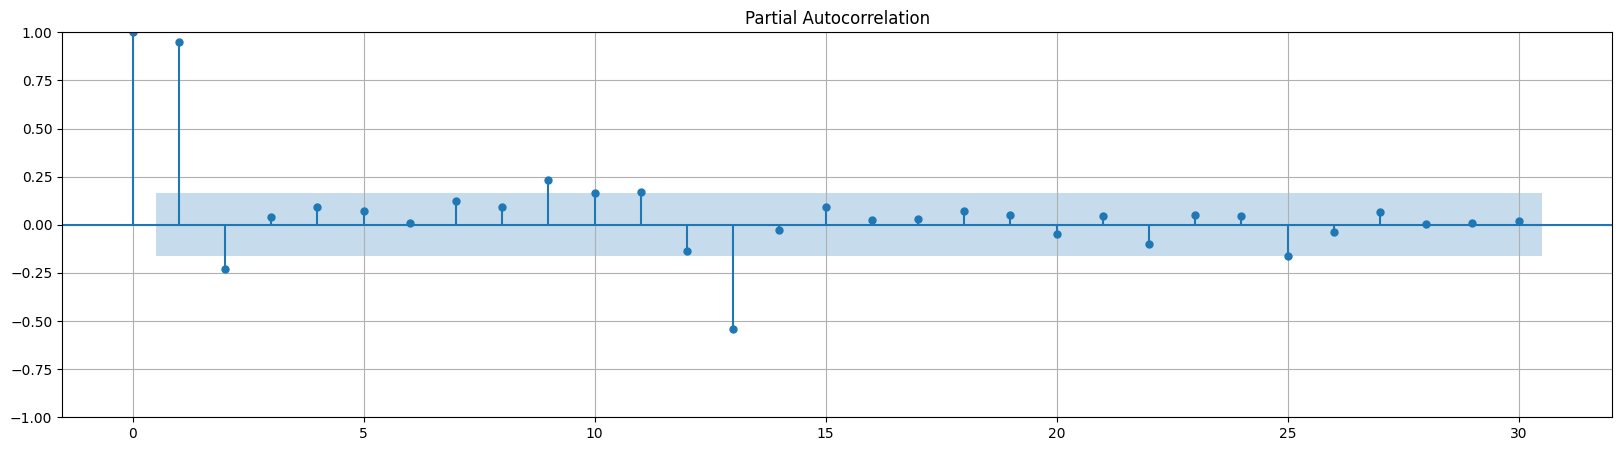

In [39]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(time_series_data['#Passengers'],ax=plt.gca(),lags=30)
plt.show()

### NON-SEASONAL DIFFERENCE

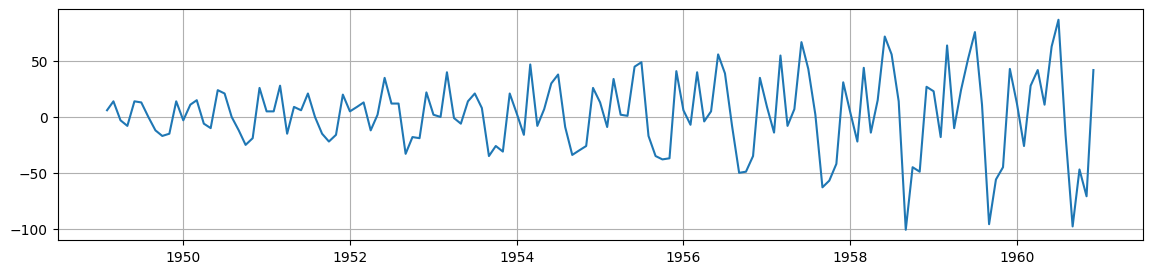

In [40]:
#NON-SEASONAL DIFFERENCE
diff = time_series_data['#Passengers'].diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [41]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(diff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


In [42]:
from statsmodels.tsa.stattools import kpss
kp = kpss(diff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_20652\3926645510.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


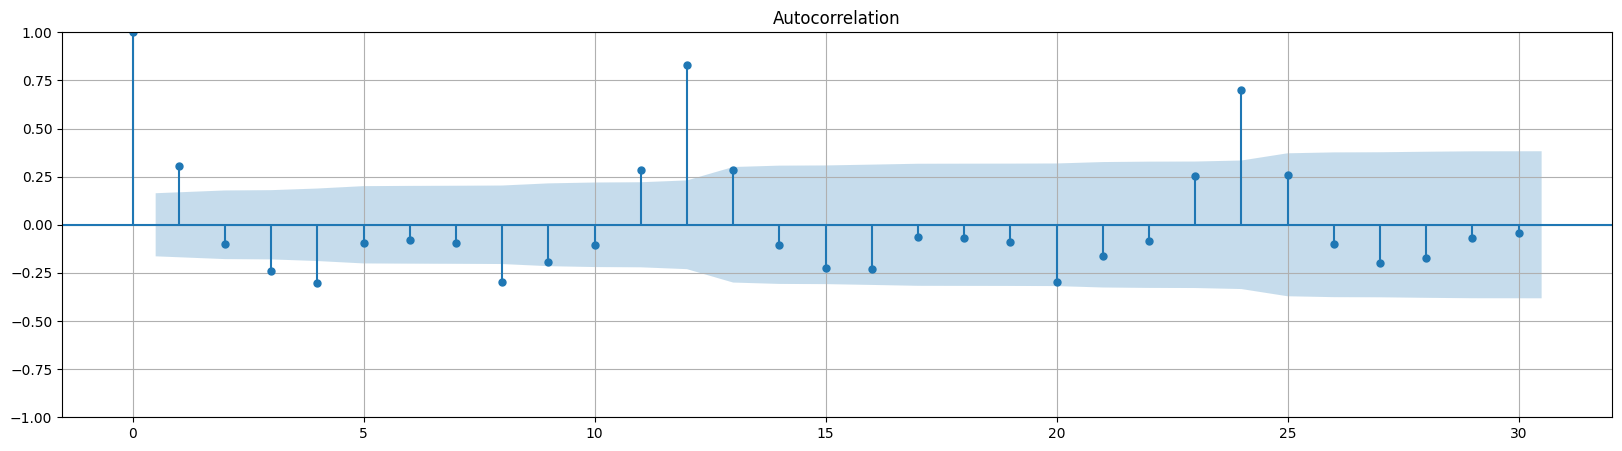

In [43]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff,ax=plt.gca(),lags=30)
plt.show()

In [47]:
#The series is not yet stationary since there are spikes 

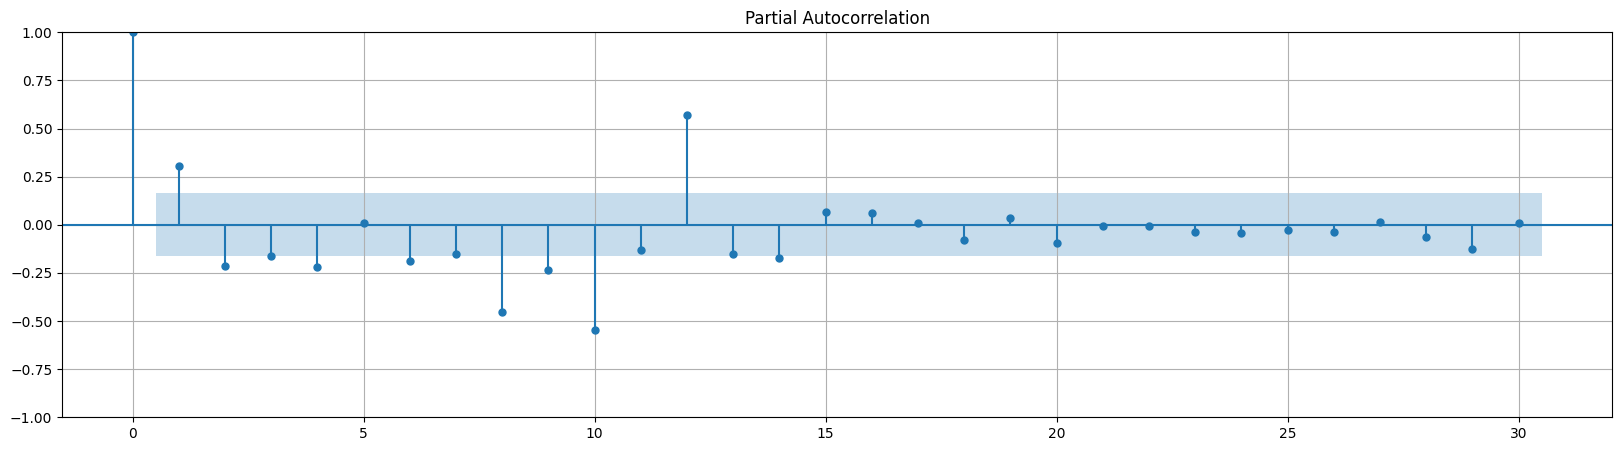

In [44]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(diff,ax=plt.gca(),lags=30)
plt.show()

#### SEASONAL DIFFERENCE

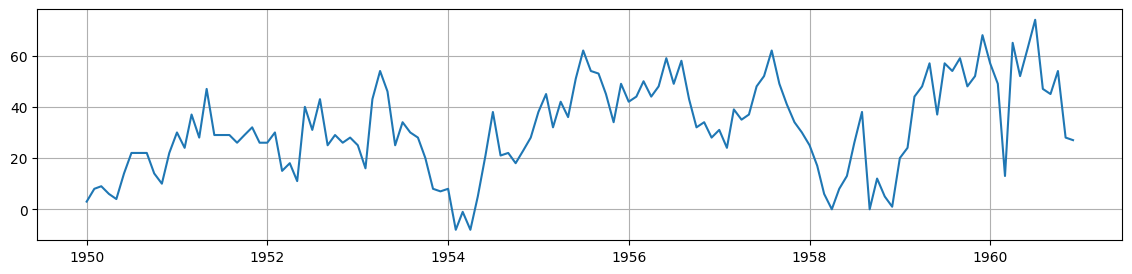

In [49]:
#SEASONAL DIFFERENCE
sdiff = time_series_data['#Passengers'].diff(periods = 12).dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [50]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(sdiff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

# ADF Suggest : Series is statinory

ADF Statistic: -3.383020726492481
p-value: 0.011551493085514954


In [51]:
from statsmodels.tsa.stattools import kpss
kp = kpss(sdiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

#Seires is not stationary

p-value for KPSS test (untransformed) =  0.034099994223604005


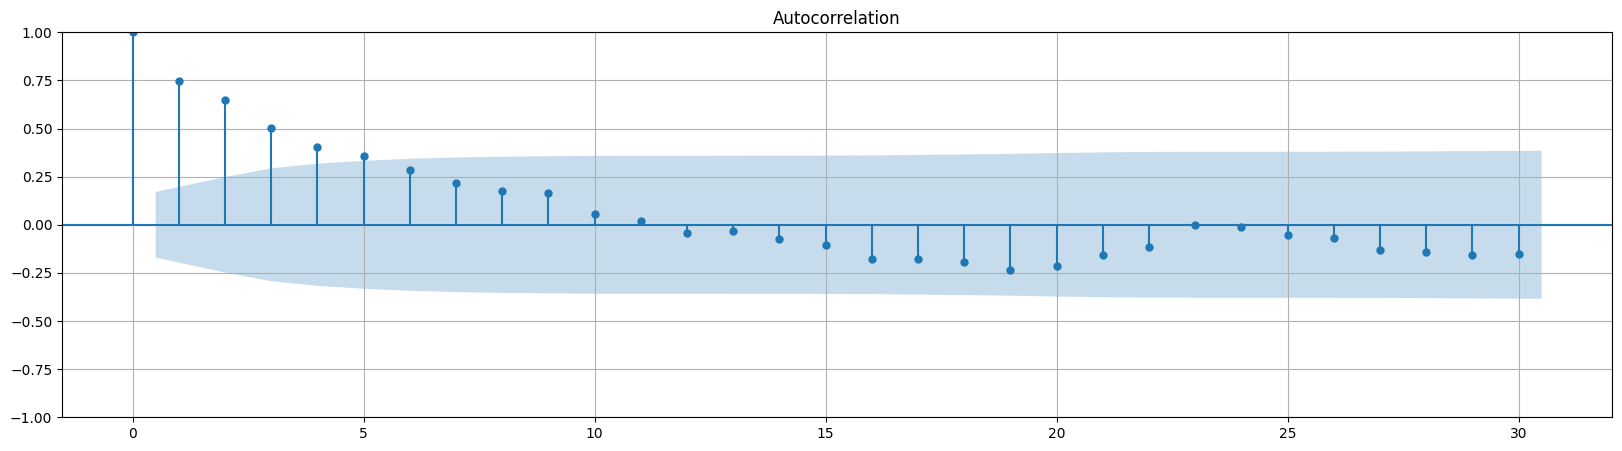

In [52]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sdiff,ax=plt.gca(),lags=30)
plt.show()

#Plt Suggest: Series is not Stationary

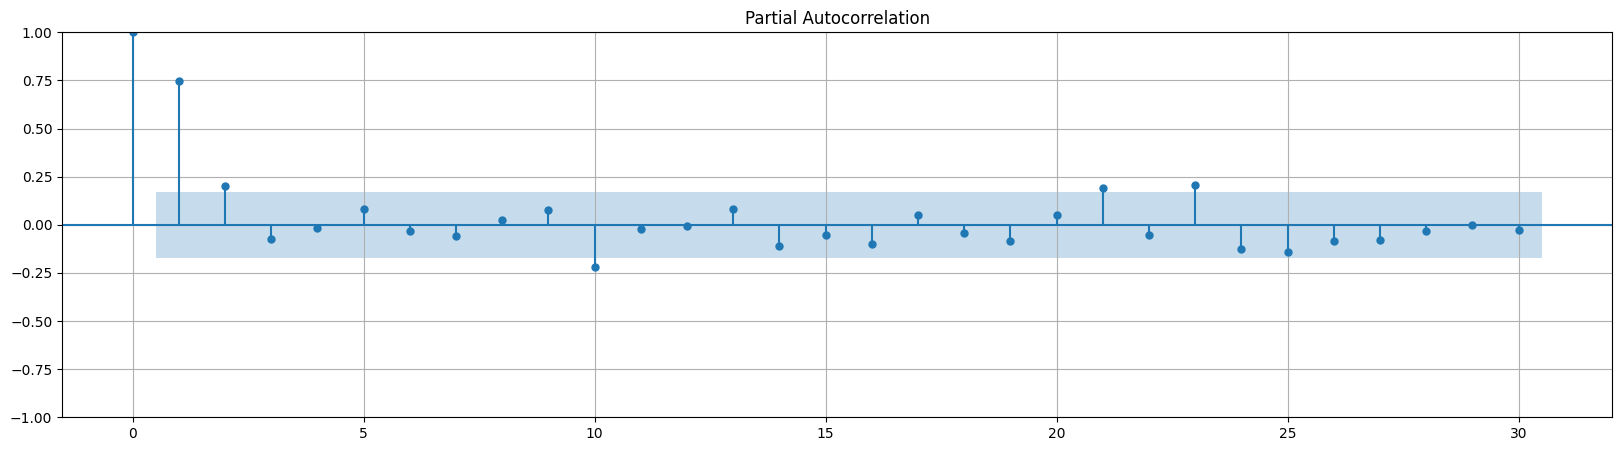

In [53]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(sdiff,ax=plt.gca(),lags=30)
plt.show()

### Seasonal and Non - Seasonal Differencing

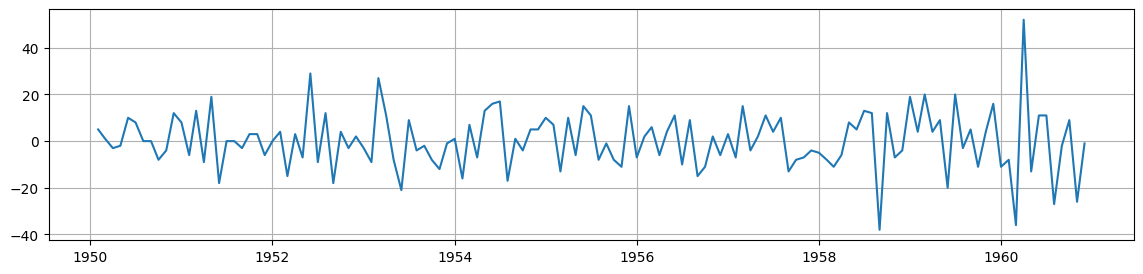

In [55]:
# Seasonal and Non - Seasonal Differencing
sdiff = time_series_data['#Passengers'].diff(periods = 12).dropna()
sddiff = sdiff.diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sddiff)
plt.show()

In [57]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(sddiff)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

# ADF Suggest : Series is statinory

ADF Statistic: -15.595618083746334
p-value: 1.8565116001234705e-28


In [58]:
from statsmodels.tsa.stattools import kpss
kp = kpss(sddiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

#Seires is trend stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_20652\2729727253.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


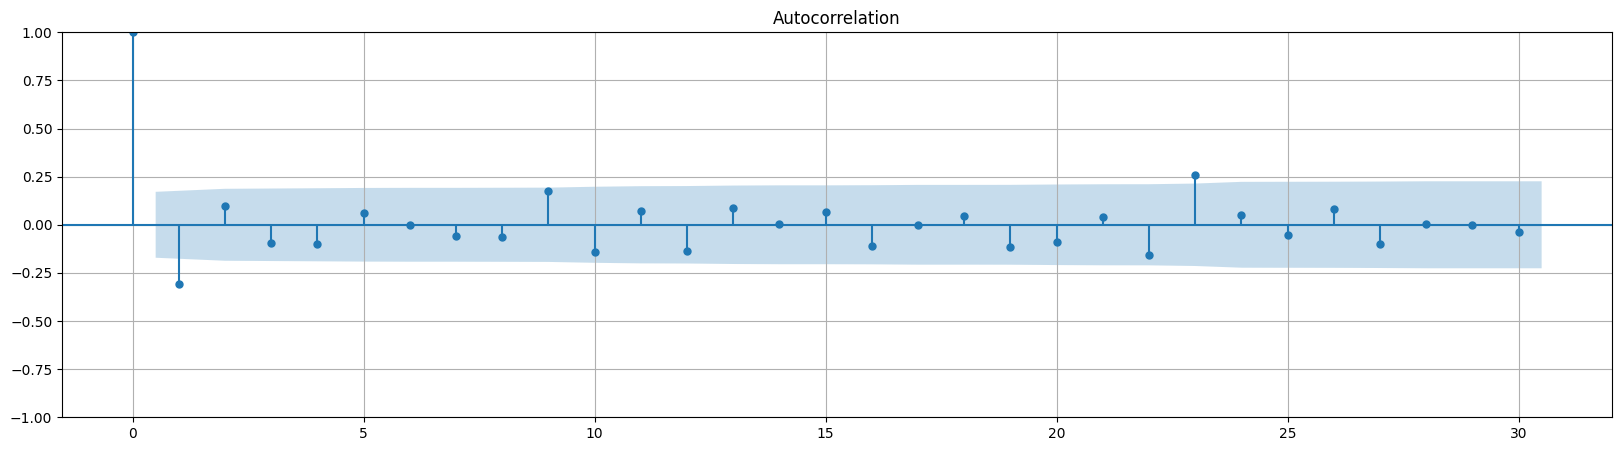

In [59]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sddiff,ax=plt.gca(),lags=30)
plt.show()

#Plt Suggest: Series is Stationary

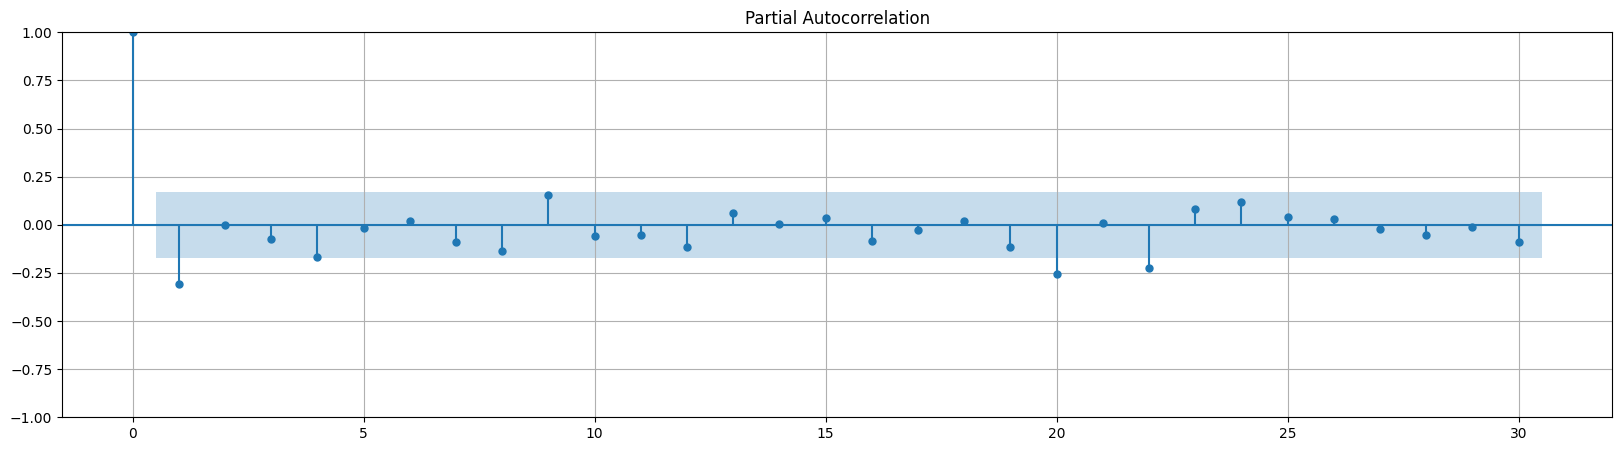

In [61]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(sddiff,ax=plt.gca(),lags=30)
plt.show()
#Plt Suggest: Series is Stationary/